- clustering iris dataset using k-means, DBSCAN, and OPTICS.
- clustering penguins dataset in the same way.

# **Clustering Iris Dataset:**

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans, DBSCAN, OPTICS, cluster_optics_dbscan

In [2]:
import matplotlib
import sklearn

print(f"Seaborn Version: {sns.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"Numpy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")

Seaborn Version: 0.13.2
Matplotlib Version: 3.10.8
Numpy Version: 2.4.2
Pandas Version: 3.0.0
Scikit-Learn Version: 1.8.0


In [3]:
iris = sns.load_dataset("iris")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


**Iris Flower Species:**

<img src="./images/iris_flower_species.png" alt="isolated" width="800">

So we wanna do clustering to see how many clusters can we found using this data and which algorithm works best on this dataset so we can extract insights from this exploration.

### **1. Checking and Fixing Data Types:**

In [4]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [5]:
# shape of the dataset

iris.shape

(150, 5)

In [6]:
print("Dataset Categories:")

iris.dtypes

Dataset Categories:


sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

Species variable is categorical and we should make its data type to categorical to save space and better analysis.

In [7]:
print("Frequency of each category in species variable:")

iris['species'].value_counts() # there are three cats in this variable

Frequency of each category in species variable:


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [8]:
iris['species'] = iris['species'].astype("category")

In [9]:
print("Data types after processing:")

iris.dtypes

Data types after processing:


sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object

### **2. Checking for Missing Data:**

Text(0.5, 1.0, 'Missing Values Matrix')

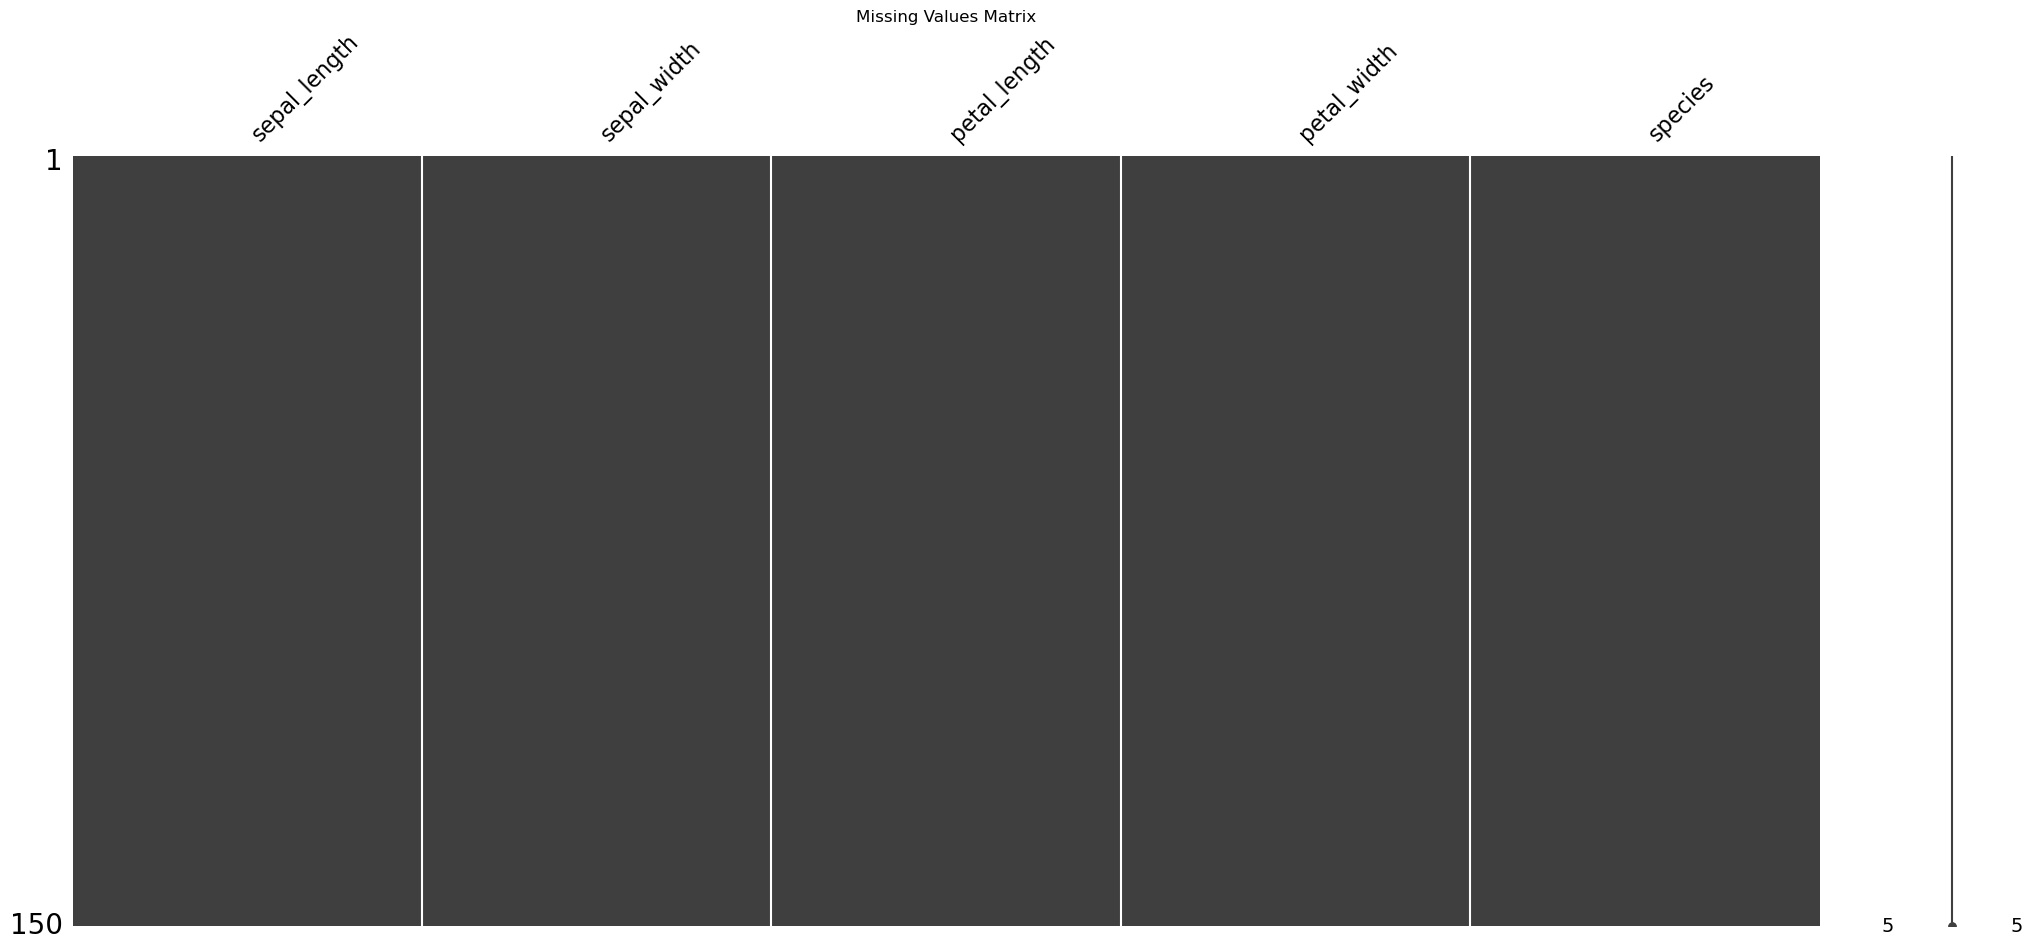

In [10]:
from missingno import matrix

matrix(iris)
plt.title("Missing Values Matrix")

In [11]:
print("Frequency of Missing Values:")

iris.isnull().sum()

Frequency of Missing Values:


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

There is no missing values is this dataset and the data set is `clean`.

### **3. Data Distributions:**

In [12]:
print("Statistical Characteristics of the data:")

iris.describe()

Statistical Characteristics of the data:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Text(0.5, 0.98, 'Pair Plot by the Species')

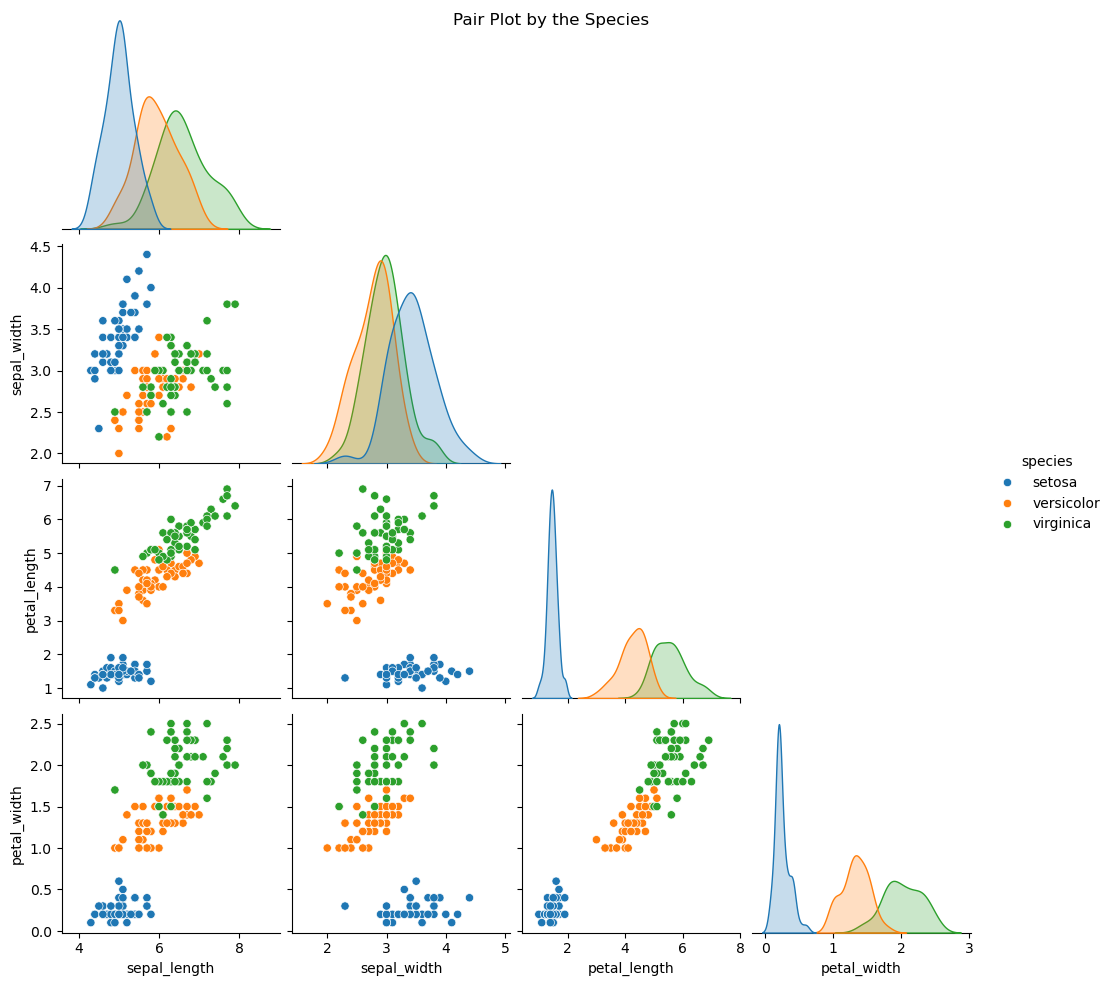

In [19]:
sns.pairplot(
    data=iris,
    hue="species",
    diag_kind="kde",
    corner=True
)
plt.suptitle("Pair Plot by the Species")

We can see that in distributions petal length and petal width of the Setosa specie are smaller than two other species in general, Virginica specie petal length and petal width have bigger values and in general we can say we can separate these two species (Setosa and Virginica) very good using there two variables. for Versicolor specie we can say petal length and petal width variables have bigger values than Setosa species but they have some collisions with Virginica specie but in general there two variables of the Versicolor specie have bigger values than the Setosa specie and smaller values than the Virginica specie.

Sepal length of the Setosa specie generally has smaller values than the Virginica specie and could be another great parameter to cluster these species in different clusters.

We can say for the task of clustering using petal length is not very useful cause there is no bold difference between species in this variable but we will test it in the clustering task later.

Text(0.5, 1.0, 'Correlation Plot')

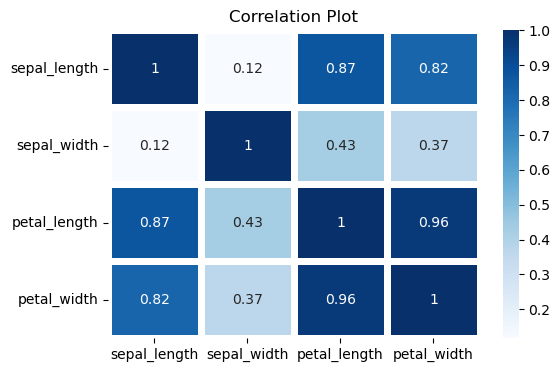

In [15]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    data=iris.drop("species", axis=1).corr().abs(),
    cmap="Blues",
    annot=True,
    linewidths=5
)
plt.title("Correlation Plot")

We can see that the highest correlation between variables is between petal length and petal width and there is a big relationship here, this correlation is obvious in both pair plot and correlation matrix.

There is a great correlation between petal length and sepal length too, looking at the pair plot we can see that this correlation is mostly in Versicolor and Virginica species and there is no great correlation between petal and sepal lengths in the Setosa specie, although it could be because of this facy that petal length and sepal length variables has small values in this specie and we can't see the correlation using visuaization propriately.

Text(0.5, 0.98, 'Pair Plot of Setosa Specie')

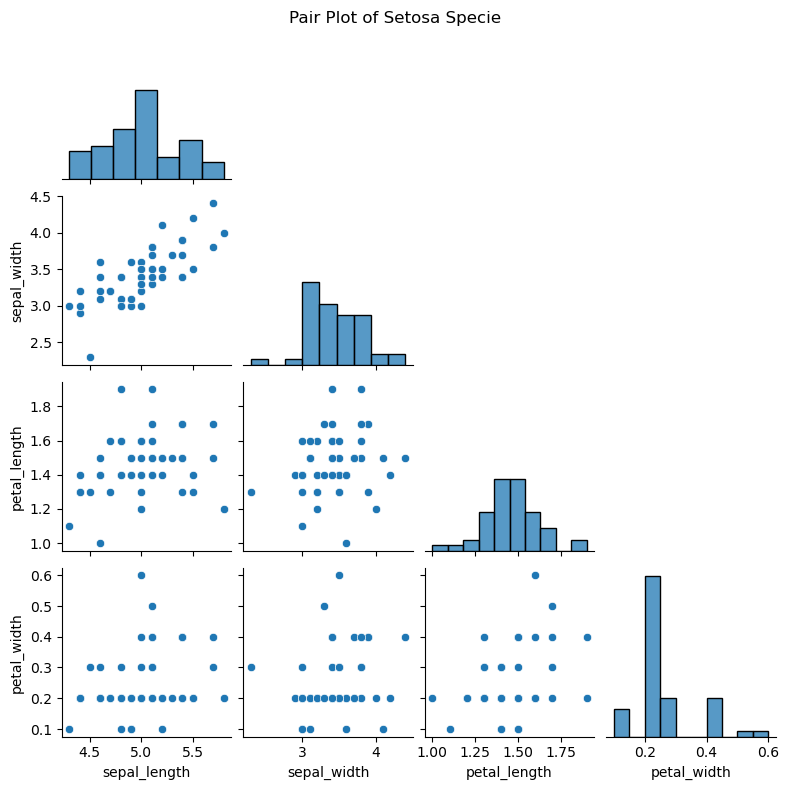

In [32]:
iris_setosa = iris[iris['species'] == "setosa"]

sns.pairplot(data=iris_setosa, corner=True, height=2, aspect=1)
plt.suptitle("Pair Plot of Setosa Specie")

Text(0.5, 1.0, 'Setosa Specie Correlation Plot')

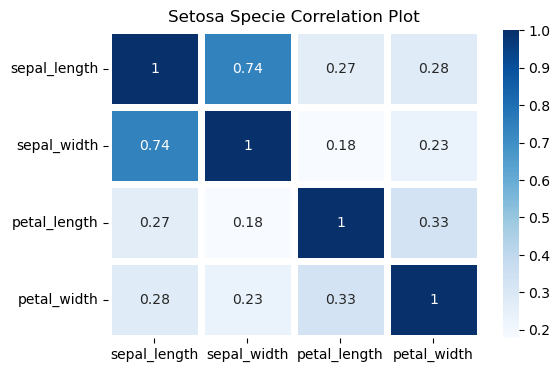

In [35]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    data=iris_setosa.drop("species", axis=1).corr().abs(),
    cmap="Blues",
    annot=True,
    linewidths=5
)
plt.title("Setosa Specie Correlation Plot")

We can Also see a great correlation between sepal length and sepal width of the Setosa specie.

### **4. Clustering:**

### 4.1 Clustering Using K-Means:

In [48]:
# loading the data
X = iris.loc[:, 'sepal_length':'petal_width'].to_numpy()

# scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# training the model
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [83]:
from collections import Counter

clusters_list = [cluster for cluster in np.unique(kmeans.labels_) if cluster !=-1]
if -1 in Counter(kmeans.labels_):
    n_noise_points = Counter(kmeans.labels_)[0]
else:
    n_noise_points = 0

print(f"Number of Clusters: {len(clusters_list)}")
print(f"Number of Noise Points: {n_noise_points}")

Number of Clusters: 3
Number of Noise Points: 0
